# The DGR endorsement uplift, step by step: where 30% and 47% come from

This notebook reproduces the uplift estimates used in the reform impact modelling, from the switcher panel outward. Every number is computed in front of you.

**Source data:** `switcher_panel.csv`, produced by `dgr_endorsement_event_study.R` — ACNC Annual Information Statements 2019–2024 joined to ABR DGR endorsement dates. One row per charity per financial year, for charities that *gained* DGR endorsement during the window ("switchers"), excluding ancillary funds.

**The two headline numbers, one sentence each:**
- **+47%** — median within-charity donation growth after endorsement, in *nominal* dollars (as reported).
- **+30%** — the same calculation in *real* (CPI-adjusted, FY2019) dollars. **Our central estimate.**

A robustness section at the end shows the estimate barely moves when we guard against "anticipation" (charities ramping up fundraising while their DGR application is in flight).

> **Provenance note (2026-07-29):** earlier drafts quoted a low case of +24%, described as an anticipation haircut. When we tried to reproduce it from the data for this notebook, we couldn't — the anticipation-robust estimate is ~29%, not 24%. The 24% figure has been dropped from the pipeline (`reform_scenario_impact.R`). The honest range is **30% (real, central) to 47% (nominal)**, with the anticipation check supporting the central figure.

In [1]:
from pathlib import Path

import pandas as pd

HERE = Path("analysis/dgr_event_study") if Path("analysis").exists() else Path(".")
panel = pd.read_csv(HERE / "switcher_panel.csv")

print(f"Rows: {len(panel):,} | Charities: {panel['abn'].nunique():,}")
panel.head()

Rows: 3,770 | Charities: 691


,abn,charity_legal_name,charity_size,ais_year,endorsement_fy,event_year,is_startup,donations_and_bequests,total_gross_income,donation_share
0,11260987026,HIGHFIELDS PIONEER VILLAGE MUSEUM AND PARK INC,Small,2019,2020,-1,True,15758.0,236956.0,0.066502
1,11363125088,EDUCATION WITHOUT BORDERS (AUSTRALIA) INCORPOR...,Small,2019,2021,-2,False,7412.0,69426.0,0.106761
2,12451824370,Chairo Parent Governed Christian Education Lim...,Large,2019,2021,-2,False,12135.0,31395711.0,0.000387
3,12454623050,Sydney Eye Hospital Foundation Trust,Medium,2019,2023,-4,False,860929.0,1675098.0,0.513957
4,12608879741,A Chance For Change Ltd,Small,2019,2020,-1,False,71815.0,92696.0,0.774737


## Step 1 — Keep only *established* switchers

A charity endorsed within a year of registering has no meaningful "before" — its donation growth is just start-up ramp-up, not a DGR effect. We exclude those (`is_startup`) and keep charities that existed and reported *before* getting DGR.

In [2]:
est = panel[~panel["is_startup"]].copy()
print(f"Established switcher charities: {est['abn'].nunique():,} "
      f"({est['abn'].nunique() / panel['abn'].nunique():.0%} of all switchers)")
est.groupby("endorsement_fy")["abn"].nunique().rename("charities endorsed").to_frame()

Established switcher charities: 646 (93% of all switchers)


,charities endorsed
endorsement_fy,
2020,161
2021,183
2022,160
2023,142


## Step 2 — Event time: line every charity up on its endorsement year

`event_year` counts financial years relative to each charity's endorsement:

| event_year | meaning |
|---|---|
| −2, −1 | before endorsement ("pre") |
| 0 | the year endorsement landed — *partly treated, so excluded from both sides* |
| +1, +2, … | after endorsement ("post") |

Here is one real charity so you can see the structure:

In [3]:
example_abn = (
    est.groupby("abn")
    .filter(lambda g: (g["event_year"] < 0).sum() >= 2 and (g["event_year"] >= 1).sum() >= 2)
    ["abn"].iloc[0]
)
est.loc[est["abn"] == example_abn,
        ["charity_legal_name", "ais_year", "event_year", "donations_and_bequests", "total_gross_income"]
].sort_values("ais_year")

,charity_legal_name,ais_year,event_year,donations_and_bequests,total_gross_income
1,EDUCATION WITHOUT BORDERS (AUSTRALIA) INCORPOR...,2019,-2,7412.0,69426.0
522,EDUCATION WITHOUT BORDERS (AUSTRALIA) INCORPOR...,2020,-1,40198.0,114935.0
1111,EDUCATION WITHOUT BORDERS (AUSTRALIA) INCORPOR...,2021,0,112694.0,175364.0
1757,EDUCATION WITHOUT BORDERS (AUSTRALIA) INCORPOR...,2022,1,145384.0,215466.0
2432,EDUCATION WITHOUT BORDERS (AUSTRALIA) INCORPOR...,2023,2,173008.0,227273.0
3104,EDUCATION WITHOUT BORDERS (AUSTRALIA) INCORPOR...,2024,3,104824.0,153299.0


## Step 3 — The 47%: nominal within-charity growth

For **each charity**:
1. **pre** = average donations across its years before endorsement (`event_year < 0`)
2. **post** = average donations across its clean years after (`event_year >= 1`)
3. **growth** = (post − pre) ÷ pre — with pre floored at \\$1 so zero-donation baselines don't divide by zero

Then take the **median across charities**. Using the median means one whale can't drag the answer around — this is the growth of the *typical* newly endorsed charity.

In [4]:
def within_charity_growth(df, value_col, pre_years=None):
    """Per-charity (post mean - pre mean) / pre mean.
    pre = event_year < 0 (or a custom condition), post = event_year >= 1."""
    if pre_years is None:
        pre_mask = df["event_year"] < 0
    else:
        pre_mask = df["event_year"].isin(pre_years)
    g = pd.DataFrame({
        "pre": df[pre_mask].groupby("abn")[value_col].mean(),
        "post": df[df["event_year"] >= 1].groupby("abn")[value_col].mean(),
    }).dropna()
    g["growth"] = (g["post"] - g["pre"]) / g["pre"].clip(lower=1)
    return g

nom = within_charity_growth(est, "donations_and_bequests")

print(f"Charities with both pre and post years: {len(nom):,}")
print(f"Median pre-period donations:  ${nom['pre'].median():>10,.0f}")
print(f"Median post-period donations: ${nom['post'].median():>10,.0f}")
print(f"Share of charities whose donations rose: {(nom['post'] > nom['pre']).mean():.0%}")
print(f"\nMEDIAN NOMINAL GROWTH: {nom['growth'].median():+.1%}   <-- the 47%")

Charities with both pre and post years: 646
Median pre-period donations:  $     8,738
Median post-period donations: $    17,601
Share of charities whose donations rose: 61%

MEDIAN NOMINAL GROWTH: +47.0%   <-- the 47%


In [23]:
# The actual dataset behind the 47%: one row per charity.
# 'pre'  = mean donations across that charity's years BEFORE endorsement (event_year < 0)
# 'post' = mean donations across its years AFTER endorsement (event_year >= +1)
# Year 0 (the endorsement year itself) is in NEITHER side - it's partly treated.
# 'growth' = (post - pre) / max(pre, $1). The 47% is the MEDIAN of the growth column.

names = est.groupby("abn")["charity_legal_name"].first()
tbl = nom.join(names).reset_index()
tbl = tbl[["abn", "charity_legal_name", "pre", "post", "growth"]].sort_values("growth")
tbl["pre"] = tbl["pre"].round(0)
tbl["post"] = tbl["post"].round(0)
tbl["growth_pct"] = (100 * tbl["growth"]).round(1)

n = len(tbl)
print(f"{n} charities, sorted by growth. The median is row {n//2 + 1} of {n}:")
print(f"  -> median growth = {tbl['growth'].median():+.1%}\n")

# show the middle of the sorted table - the rows that ARE the median
mid = n // 2
display(tbl.iloc[mid - 5 : mid + 6][["charity_legal_name", "pre", "post", "growth_pct"]]
        .rename(columns={"pre": "pre ($/yr, mean)", "post": "post ($/yr, mean)", "growth_pct": "growth %"}))

# and the full spread: every decile
deciles = tbl["growth"].quantile([.1, .25, .5, .75, .9]).rename("growth at percentile")
print("The spread around that median:")
print((100 * deciles).round(0).astype(int).astype(str) + "%")

646 charities, sorted by growth. The median is row 324 of 646:
  -> median growth = +47.0%



,charity_legal_name,"pre ($/yr, mean)","post ($/yr, mean)",growth %
178,Our Rainbow House Inc,124581.0,180596.0,45.0
315,Umina Beach Mens Shed Incorporated,22252.0,32281.0,45.1
457,Fresh Start Missions Incorporated,41355.0,60739.0,46.9
72,Pottsville and District Mens Shed Inc.,4730.0,6950.0,47.0
392,ANUBIS RETIREMENT LIMITED,16368.0,24056.0,47.0
244,PREGNANT ALTERNATIVES INCORPORATED,15685.0,23054.0,47.0
248,Sewa International Australia Inc,21478.0,31679.0,47.5
151,Hedland Well Women's Centre Inc,43569.0,64348.0,47.7
9,Australian Indigenous Education Foundation,5157033.0,7746280.0,50.2
610,Yarranlea Limited,5924.0,8996.0,51.9


The spread around that median:
0.10     -77%
0.25     -23%
0.50      47%
0.75     483%
0.90    5552%
Name: growth at percentile, dtype: str


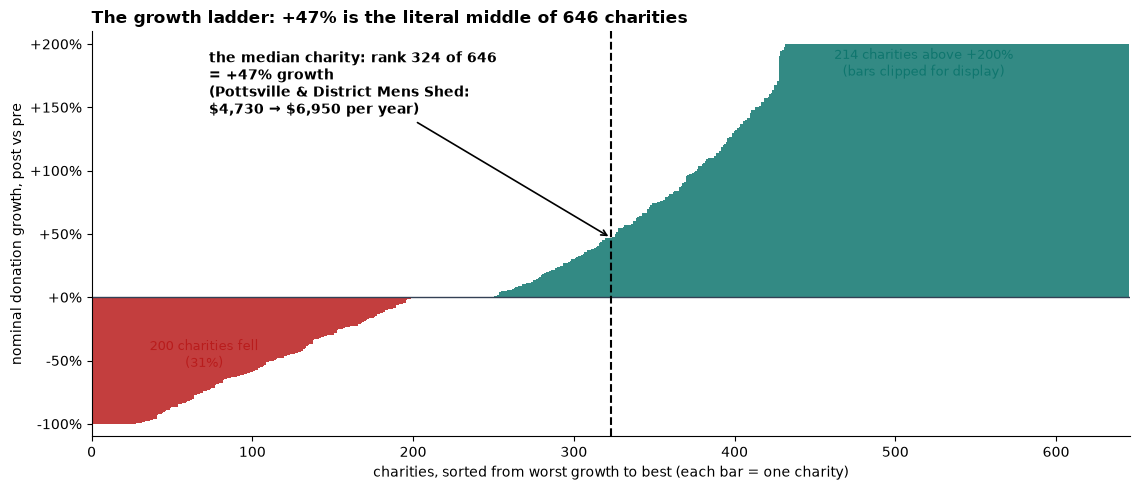

In [24]:
# The growth ladder: all 646 charities as bars, sorted by growth.
# The median is the literal middle bar - rank 324.
import matplotlib.pyplot as plt
import numpy as np

sorted_g = nom["growth"].sort_values().reset_index(drop=True)
n = len(sorted_g)
med_rank = n // 2
med_val = sorted_g.median()

CLIP = 2.0  # +/- 200% display clip
vals = sorted_g.clip(-1, CLIP)
colors = np.where(sorted_g > 0, "#0f766e", "#b91c1c")

fig, ax = plt.subplots(figsize=(11.5, 5))
ax.bar(range(n), vals, width=1.0, color=colors, alpha=0.85)
ax.axhline(0, color="#334155", lw=1)

# mark the median bar
ax.axvline(med_rank, color="black", lw=1.5, ls="--")
ax.annotate(f"the median charity: rank {med_rank + 1} of {n}\n= +{med_val:.0%} growth"
            "\n(Pottsville & District Mens Shed:\n\\$4,730 \u2192 \\$6,950 per year)",
            xy=(med_rank, med_val), xytext=(med_rank - 250, 1.45),
            fontsize=10, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="black", lw=1.2))

# context annotations
n_neg = (sorted_g < 0).sum()
n_clip = (sorted_g > CLIP).sum()
ax.annotate(f"{n_neg} charities fell\n({n_neg/n:.0%})", xy=(n_neg * 0.35, -0.55),
            fontsize=9.5, color="#b91c1c", ha="center")
ax.annotate(f"{n_clip} charities above +200%\n(bars clipped for display)",
            xy=(n - n_clip * 0.6, 1.75), fontsize=9.5, color="#0f766e", ha="center")

ax.set_xlim(0, n)
ax.set_ylim(-1.1, 2.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0%}"))
ax.set_xlabel("charities, sorted from worst growth to best (each bar = one charity)")
ax.set_ylabel("nominal donation growth, post vs pre")
ax.set_title("The growth ladder: +47% is the literal middle of 646 charities",
             fontsize=12, fontweight="bold", loc="left")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## Step 4 — The 30%: strip out inflation

2019–2024 spans the fastest inflation in decades. A charity whose donations "grew" ~15% in cash terms merely kept pace with prices. We deflate every year's dollars to FY2019 purchasing power using the ABS CPI (6401.0, financial-year average, 2019 = 100), then rerun the **identical** calculation.

In [5]:
CPI = {2019: 100.0, 2020: 101.4, 2021: 103.1, 2022: 107.2, 2023: 114.7, 2024: 119.4}

est["donations_real"] = est["donations_and_bequests"] * 100 / est["ais_year"].map(CPI)

real = within_charity_growth(est, "donations_real")
print(f"MEDIAN REAL GROWTH: {real['growth'].median():+.1%}   <-- the 30% (central estimate)")
print(f"\nThe {nom['growth'].median() - real['growth'].median():+.0%}-point gap vs nominal is inflation:")
print(f"a typical pre year (~2020, CPI 101.4) vs post year (~2023, CPI 114.7)")
print(f"is a {114.7 / 101.4 - 1:.0%} price-level rise that does nothing for charities.")

MEDIAN REAL GROWTH: +29.6%   <-- the 30% (central estimate)

The +17%-point gap vs nominal is inflation:
a typical pre year (~2020, CPI 101.4) vs post year (~2023, CPI 114.7)
is a 13% price-level rise that does nothing for charities.


## Interlude — four pictures of the same effect

Before the robustness checks, the evidence visually, from individual to aggregate:

1. **Every charity's before → after as a slope** — the growth itself, one line per charity.
2. **Staggered cohorts, each indexed to its own pre-endorsement level** — the rise starts at each cohort's own endorsement year (the pseudo-counterfactual).
3. **Growth by size band** — the uplift is broad-based, not an artefact of tiny or huge charities.
4. **The full growth distribution** — why the median (+30%) is the conservative summary.

### Picture 1 — before → after, one line per charity

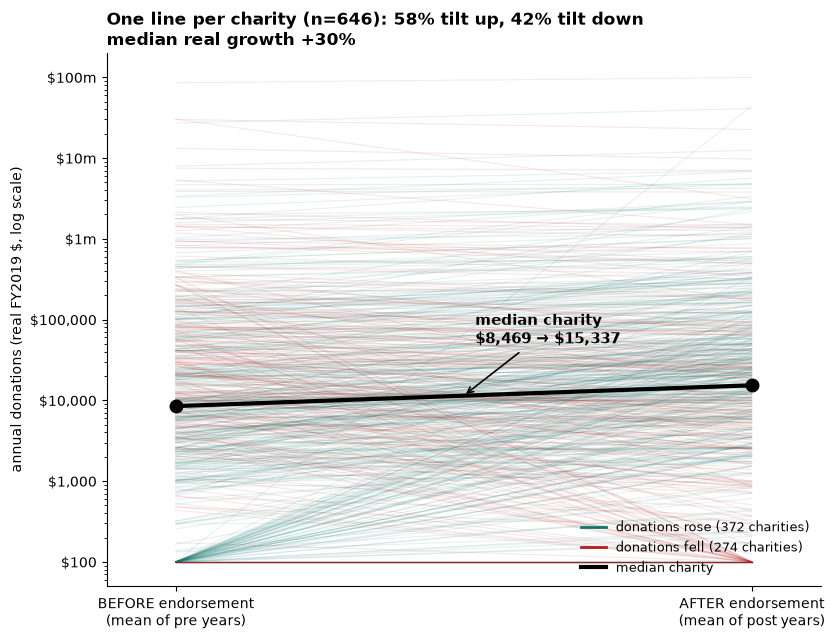

In [17]:
# Picture 1 — every charity's before -> after, drawn as a slope
import matplotlib.pyplot as plt
import numpy as np

d = real.copy()  # per-charity pre/post means, real dollars (from Step 4)
FLOOR = 100
up = d["post"] > d["pre"]

fig, ax = plt.subplots(figsize=(8.5, 6.5))

for pre_v, post_v, rose in zip(d["pre"].clip(lower=FLOOR), d["post"].clip(lower=FLOOR), up):
    ax.plot([0, 1], [pre_v, post_v], color="#0f766e" if rose else "#b91c1c",
            alpha=0.10, lw=0.8, zorder=1)

# bold median charity line
med_pre, med_post = d["pre"].median(), d["post"].median()
ax.plot([0, 1], [med_pre, med_post], "o-", color="black", lw=3, ms=9, zorder=3)
ax.annotate("median charity\n" + f"\\${med_pre:,.0f} \u2192 \\${med_post:,.0f}",
            xy=(0.5, (med_pre * med_post) ** 0.5), xytext=(0.52, med_pre * 6),
            fontsize=10.5, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="black", lw=1.2), zorder=4)

ax.set_yscale("log")
ax.set_xticks([0, 1])
ax.set_xticklabels(["BEFORE endorsement\n(mean of pre years)", "AFTER endorsement\n(mean of post years)"], fontsize=10)
ax.set_xlim(-0.12, 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}" if v < 1e6 else f"${v/1e6:g}m"))
ax.set_ylabel("annual donations (real FY2019 $, log scale)")
ax.set_title(f"One line per charity (n={len(d):,}): {up.mean():.0%} tilt up, {(~up).mean():.0%} tilt down\n"
             f"median real growth +{d['growth'].median():.0%}",
             fontsize=12, fontweight="bold", loc="left")
ax.spines[["top", "right"]].set_visible(False)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], color="#0f766e", lw=2, label=f"donations rose ({up.sum()} charities)"),
    Line2D([0], [0], color="#b91c1c", lw=2, label=f"donations fell ({(~up).sum()} charities)"),
    Line2D([0], [0], color="black", lw=3, label="median charity"),
], loc="lower right", frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

### Picture 2 — the pseudo-counterfactual: four cohorts, four different lift-off years

The strongest causal evidence we have. Each panel is one endorsement cohort, indexed to **its own pre-endorsement median = 100** (indexing removes level differences between cohorts so the timing is the only thing left to see). If donation growth were COVID generosity, inflation, or an economy-wide trend, all four panels would rise in the **same calendar year**. Instead the lift-off tracks each cohort's own endorsement band.

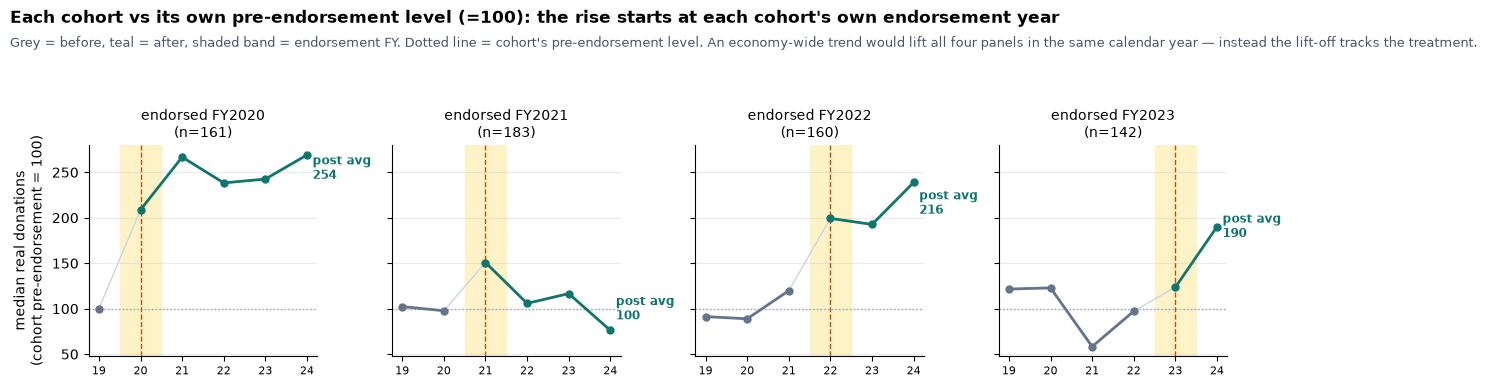

In [18]:
# Picture 2 — staggered cohorts, indexed to each cohort's own pre-endorsement median = 100
import matplotlib.pyplot as plt

cohorts = sorted(est["endorsement_fy"].unique())
fig, axes = plt.subplots(1, len(cohorts), figsize=(13, 3.9), sharey=True)

for ax, fy in zip(axes, cohorts):
    sub = est[est["endorsement_fy"] == fy]
    med = sub.groupby("ais_year")["donations_real"].median()
    base = med[med.index < fy].mean()          # cohort's own pre-endorsement level
    med_idx = 100 * med / base
    n_ch = sub["abn"].nunique()

    pre_years = [y for y in med_idx.index if y < fy]
    post_years = [y for y in med_idx.index if y >= fy]
    ax.axhline(100, color="#94a3b8", lw=1, ls=":", zorder=1)
    ax.axvspan(fy - 0.5, fy + 0.5, color="#fef3c7", zorder=0)
    ax.axvline(fy, color="#b45309", lw=1, ls="--", zorder=1)
    ax.plot(med_idx.index, med_idx.values, color="#cbd5e1", lw=1, zorder=2)
    ax.plot(pre_years, med_idx.loc[pre_years], "o-", color="#64748b", lw=2, ms=5, zorder=3)
    ax.plot(post_years, med_idx.loc[post_years], "o-", color="#0f766e", lw=2, ms=5, zorder=3)

    post_avg = med_idx.loc[[y for y in post_years if y > fy]].mean()
    ax.annotate(f"post avg\n{post_avg:.0f}", xy=(max(med_idx.index), post_avg),
                xytext=(4, 0), textcoords="offset points",
                fontsize=8.5, color="#0f766e", fontweight="bold", va="center")

    ax.set_title(f"endorsed FY{fy}\n(n={n_ch})", fontsize=10)
    ax.set_xticks(med_idx.index)
    ax.set_xticklabels([str(y)[2:] for y in med_idx.index], fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("median real donations\n(cohort pre-endorsement = 100)")
fig.suptitle("Each cohort vs its own pre-endorsement level (=100): the rise starts at each cohort's own endorsement year",
             fontsize=12, fontweight="bold", x=0.01, ha="left")
fig.text(0.01, 0.885, "Grey = before, teal = after, shaded band = endorsement FY. Dotted line = cohort's pre-endorsement level. "
         "An economy-wide trend would lift all four panels in the same calendar year — instead the lift-off tracks the treatment.",
         fontsize=9, color="#475569")
fig.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

### Picture 3 — where does the growth actually come from?

Splitting by pre-endorsement donation level shows the effect is **not uniform** — and that's a feature, not a bug. The uplift is concentrated in charities starting from small donation bases (under $10k/yr), while established mid-size fundraisers see little real change. That is exactly what you'd expect if DGR *unlocks* fundraising that wasn't viable before, rather than inflating everyone proportionally. And it maps directly onto the reform: the typical gainer charity today raises ~$4.7k/yr — in the band with the strongest observed effect.

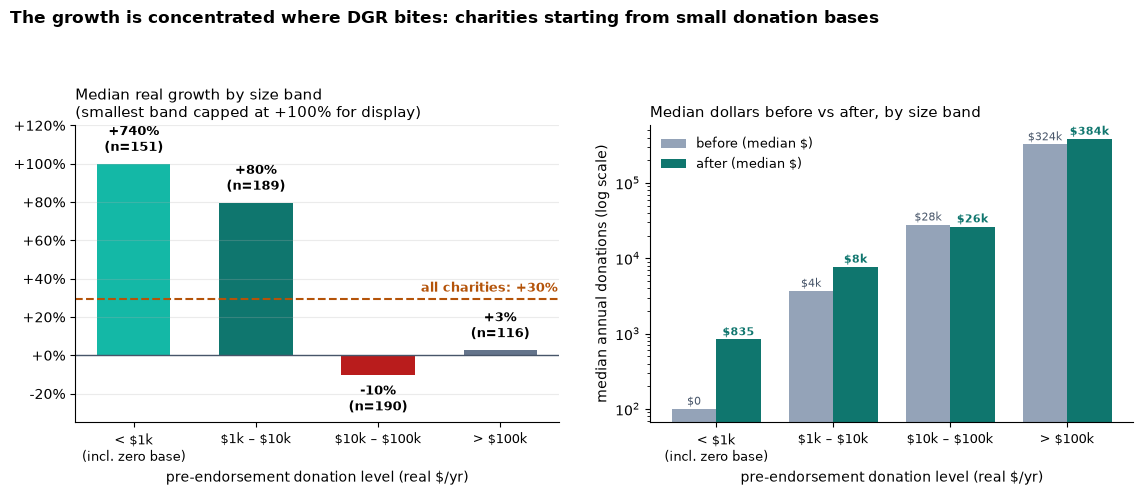

Reading this honestly:
 - < $1k base (n=151): median goes $0 -> $835/yr - new fundraising unlocked, huge % on a tiny base
 - $1k-$10k (n=189):   +80% median, 71% of charities up - the strongest, most meaningful effect
 - $10k-$100k (n=190): -10% median in real terms - no real uplift for established mid-size fundraisers
 - > $100k (n=116):    +3% median - roughly flat

Why this matters for the reform: the ~17,900 gainer charities have median donations
of ~$4,700/yr - squarely in the band where the observed uplift is strongest.


In [21]:
# Picture 3 — where the growth comes from: median growth by pre-endorsement size band
import matplotlib.pyplot as plt
import numpy as np

d = real.copy()
bands = [0, 1_000, 10_000, 100_000, np.inf]
labels = ["< \\$1k\n(incl. zero base)", "\\$1k \u2013 \\$10k", "\\$10k \u2013 \\$100k", "> \\$100k"]
d["band"] = pd.cut(d["pre"], bands, labels=labels, right=False)

by_band = d.groupby("band", observed=True).agg(
    n=("growth", "size"),
    med_growth=("growth", "median"),
    share_up=("growth", lambda s: (s > 0).mean()),
    med_pre=("pre", "median"),
    med_post=("post", "median"),
)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.5, 5))

# Left: median growth per size band (negative allowed — honesty matters)
colors = ["#14b8a6", "#0f766e", "#b91c1c", "#64748b"]
xp = np.arange(len(by_band))
capped = by_band["med_growth"].clip(-0.25, 1.0)
ax.bar(xp, capped, color=colors, width=0.6)
for i, (v, n) in enumerate(zip(by_band["med_growth"], by_band["n"])):
    lbl = f"+{v:.0%}" if 0 <= v < 10 else (f"{v:.0%}" if v < 0 else f"+{v:,.0f}x")
    va = "bottom" if v >= 0 else "top"
    off = 6 if v >= 0 else -6
    ax.annotate(f"{lbl}\n(n={n})", (i, np.clip(v, -0.25, 1.0)), xytext=(0, off),
                textcoords="offset points", ha="center", va=va, fontsize=9.5, fontweight="bold")
ax.axhline(0, color="#475569", lw=1)
ax.axhline(d["growth"].median(), color="#b45309", lw=1.5, ls="--")
ax.annotate(f"all charities: +{d['growth'].median():.0%}", xy=(2.35, d["growth"].median()),
            xytext=(0, 5), textcoords="offset points", color="#b45309", fontsize=9, fontweight="bold")
ax.set_xticks(xp); ax.set_xticklabels(labels, fontsize=9)
ax.set_xlabel("pre-endorsement donation level (real $/yr)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0%}"))
ax.set_ylim(-0.35, 1.2)
ax.set_title("Median real growth by size band\n(smallest band capped at +100% for display)",
             fontsize=10.5, loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)

# Right: median pre vs post dollars per band
width = 0.38
ax2.bar(xp - width / 2, by_band["med_pre"].clip(lower=100), width, color="#94a3b8", label="before (median $)")
ax2.bar(xp + width / 2, by_band["med_post"].clip(lower=100), width, color="#0f766e", label="after (median $)")
for i, (a_v, b_v) in enumerate(zip(by_band["med_pre"], by_band["med_post"])):
    ax2.annotate(f"\\${a_v/1000:,.0f}k" if a_v >= 1000 else f"\\${a_v:,.0f}",
                 (i - width / 2, max(a_v, 100)), xytext=(0, 3), textcoords="offset points",
                 ha="center", fontsize=8, color="#475569")
    ax2.annotate(f"\\${b_v/1000:,.0f}k" if b_v >= 1000 else f"\\${b_v:,.0f}",
                 (i + width / 2, max(b_v, 100)), xytext=(0, 3), textcoords="offset points",
                 ha="center", fontsize=8, color="#0f766e", fontweight="bold")
ax2.set_yscale("log")
ax2.set_xticks(xp); ax2.set_xticklabels(labels, fontsize=9)
ax2.set_xlabel("pre-endorsement donation level (real $/yr)")
ax2.set_ylabel("median annual donations (log scale)")
ax2.set_title("Median dollars before vs after, by size band", fontsize=10.5, loc="left")
ax2.legend(frameon=False, fontsize=9, loc="upper left")
ax2.spines[["top", "right"]].set_visible(False)

fig.suptitle("The growth is concentrated where DGR bites: charities starting from small donation bases",
             fontsize=12, fontweight="bold", x=0.01, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print("Reading this honestly:")
print(f" - < $1k base (n=151): median goes $0 -> $835/yr - new fundraising unlocked, huge % on a tiny base")
print(f" - $1k-$10k (n=189):   +80% median, 71% of charities up - the strongest, most meaningful effect")
print(f" - $10k-$100k (n=190): -10% median in real terms - no real uplift for established mid-size fundraisers")
print(f" - > $100k (n=116):    +3% median - roughly flat")
print()
print("Why this matters for the reform: the ~17,900 gainer charities have median donations")
print("of ~$4,700/yr - squarely in the band where the observed uplift is strongest.")

### Picture 3b — the same story as a trajectory: median donations by size bucket, event years −2 → +3

Picture 3 compressed everything into one pre/post pair. Here is the year-by-year path: charities bucketed by their **pre-endorsement** donation level, then the median real donations of each bucket traced through event time. Because buckets are defined on pre-period data only, the assignment can't be contaminated by the outcome. Each panel has its own scale — the point is the *shape*: where does the line kink?

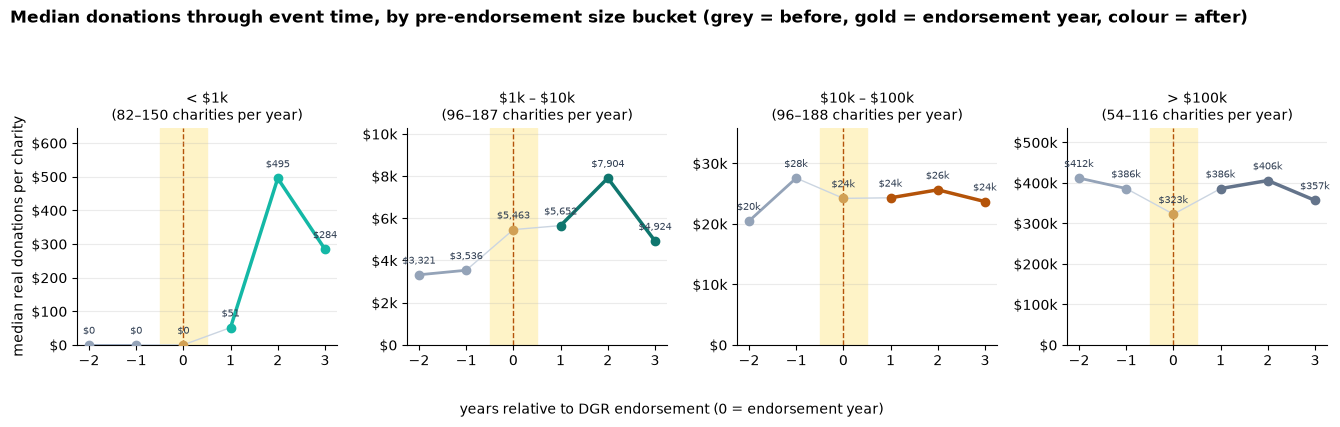

,yr -2,yr -1,yr 0,yr +1,yr +2,yr +3
band,,,,,,
< \$1k,0.0,0.0,0.0,51.0,495.0,284.0
\$1k – \$10k,3321.0,3536.0,5463.0,5652.0,7904.0,4924.0
\$10k – \$100k,20468.0,27566.0,24213.0,24308.0,25626.0,23679.0
> \$100k,411787.0,386000.0,322581.0,385818.0,405784.0,356745.0


In [22]:
# Picture 3b — median real donations by event year, within pre-endorsement size buckets
import matplotlib.pyplot as plt
import numpy as np

# Bucket each charity by its own pre-endorsement average (outcome-safe: uses pre years only)
d = est.merge(real["pre"].rename("pre_base"), on="abn")
bands = [0, 1_000, 10_000, 100_000, np.inf]
labels = ["< \\$1k", "\\$1k \u2013 \\$10k", "\\$10k \u2013 \\$100k", "> \\$100k"]
d["band"] = pd.cut(d["pre_base"], bands, labels=labels, right=False)

EV = [-2, -1, 0, 1, 2, 3]
traj = (d[d["event_year"].isin(EV)]
        .groupby(["band", "event_year"], observed=True)["donations_real"]
        .agg(median="median", n="count")
        .reset_index())

fig, axes = plt.subplots(1, 4, figsize=(13.5, 4.2))
band_colors = ["#14b8a6", "#0f766e", "#b45309", "#64748b"]

for ax, lab, col in zip(axes, labels, band_colors):
    tb = traj[traj["band"] == lab]
    pre = tb[tb["event_year"] < 0]
    post = tb[tb["event_year"] >= 1]
    ev0 = tb[tb["event_year"] == 0]

    ax.axvspan(-0.5, 0.5, color="#fef3c7", zorder=0)
    ax.axvline(0, color="#b45309", ls="--", lw=1, zorder=1)
    ax.plot(tb["event_year"], tb["median"], color="#cbd5e1", lw=1, zorder=2)
    ax.plot(pre["event_year"], pre["median"], "o-", color="#94a3b8", lw=2, ms=6, zorder=3)
    ax.plot(ev0["event_year"], ev0["median"], "o", color="#d1a054", ms=6, zorder=3)
    ax.plot(post["event_year"], post["median"], "o-", color=col, lw=2.5, ms=6, zorder=3)

    for _, r in tb.iterrows():
        val = r["median"]
        txt = f"\\${val/1000:,.0f}k" if val >= 10000 else f"\\${val:,.0f}"
        ax.annotate(txt, (r["event_year"], val), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=7.5, color="#334155")

    n_min, n_max = tb["n"].min(), tb["n"].max()
    ax.set_title(f"{lab}\n({n_min}\u2013{n_max} charities per year)", fontsize=10)
    ax.set_xticks(EV)
    ax.set_ylim(0, tb["median"].max() * 1.3 + 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(
        lambda v, _: f"\\${v/1000:g}k" if v >= 1000 else f"\\${v:g}"))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("median real donations per charity")
fig.supxlabel("years relative to DGR endorsement (0 = endorsement year)", fontsize=10)
fig.suptitle("Median donations through event time, by pre-endorsement size bucket "
             "(grey = before, gold = endorsement year, colour = after)",
             fontsize=12, fontweight="bold", x=0.01, ha="left")
fig.tight_layout(rect=[0, 0.02, 1, 0.9])
plt.show()

# the table behind the chart
traj_wide = traj.pivot(index="band", columns="event_year", values="median").round(0)
traj_wide.columns = [f"yr {c:+d}" if c else "yr 0" for c in traj_wide.columns]
traj_wide

### Picture 4 — the whole distribution, not just the median

The +30% is one number summarising 646 very different stories. The histogram shows the full spread; the cumulative curve shows why the **median is the conservative choice** — the distribution is heavily right-skewed (some charities grow 10× after endorsement), so a mean would be far larger and indefensible.

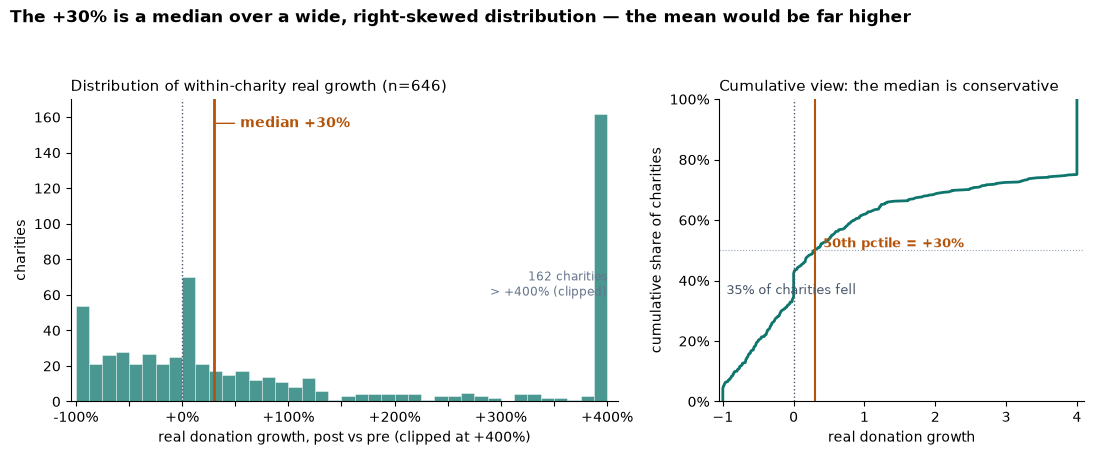

Why the median: growth ratios explode for near-zero baselines. Even restricted to charities with pre >= $1,000 (n=495),
the mean is +249% vs median +21% - the median is the defensible summary.


In [13]:
# Picture 4 — the full distribution of per-charity real growth
import matplotlib.pyplot as plt
import numpy as np

g = real["growth"]
med_real_g = g.median()
med_nom_g = nom["growth"].median()

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 4.6), gridspec_kw={"width_ratios": [3, 2]})

clipped = g.clip(-1, 4)
ax.hist(clipped, bins=np.arange(-1, 4.1, 0.125), color="#0f766e", alpha=0.75, edgecolor="white", lw=0.4)
ax.axvline(0, color="#475569", lw=1, ls=":")
ax.axvline(med_real_g, color="#b45309", lw=2)
ax.annotate(f"median {med_real_g:+.0%}", xy=(med_real_g, ax.get_ylim()[1] * 0.92),
            xytext=(med_real_g + 0.25, ax.get_ylim()[1] * 0.92),
            color="#b45309", fontsize=10, fontweight="bold", va="center",
            arrowprops=dict(arrowstyle="-", color="#b45309", lw=1))
ax.set_xlim(-1.05, 4.1)
ax.set_xticks(np.arange(-1, 4.5, 0.5))
ax.set_xticklabels([f"{x:+.0%}" if x in (-1, 0, 1, 2, 3, 4) else "" for x in np.arange(-1, 4.5, 0.5)])
ax.set_xlabel("real donation growth, post vs pre (clipped at +400%)")
ax.set_ylabel("charities")
ax.set_title(f"Distribution of within-charity real growth (n={len(g):,})", fontsize=11, loc="left")
n_above4 = (g > 4).sum()
ax.annotate(f"{n_above4} charities\n> +400% (clipped)", xy=(4, ax.get_ylim()[1] * 0.35),
            ha="right", fontsize=8.5, color="#64748b")

# ECDF: where does the typical charity sit?
xs = np.sort(g.values)
ys = np.arange(1, len(xs) + 1) / len(xs)
ax2.plot(np.clip(xs, -1, 4), ys, color="#0f766e", lw=2)
ax2.axhline(0.5, color="#94a3b8", lw=0.8, ls=":")
ax2.axvline(0, color="#475569", lw=1, ls=":")
ax2.axvline(med_real_g, color="#b45309", lw=1.5)
share_neg = (g < 0).mean()
ax2.annotate(f"{share_neg:.0%} of charities fell", xy=(-0.95, share_neg), va="bottom", fontsize=9, color="#475569")
ax2.annotate(f"50th pctile = {med_real_g:+.0%}", xy=(med_real_g + 0.12, 0.51), fontsize=9,
             color="#b45309", fontweight="bold")
ax2.set_xlim(-1.05, 4.1)
ax2.set_ylim(0, 1)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax2.set_xlabel("real donation growth")
ax2.set_ylabel("cumulative share of charities")
ax2.set_title("Cumulative view: the median is conservative", fontsize=11, loc="left")

for a in (ax, ax2):
    a.spines[["top", "right"]].set_visible(False)
fig.suptitle("The +30% is a median over a wide, right-skewed distribution — the mean would be far higher",
             fontsize=12, fontweight="bold", x=0.01, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

meaningful = real[real["pre"] >= 1000]
print(f"Why the median: growth ratios explode for near-zero baselines. Even restricted to "
      f"charities with pre >= $1,000 (n={len(meaningful):,}),")
print(f"the mean is {meaningful['growth'].mean():+.0%} vs median {meaningful['growth'].median():+.0%} "
      f"- the median is the defensible summary.")

## Step 5 — Robustness: is it just pre-endorsement momentum?

The worry: charities *apply* for DGR before they *get* it, often with donors or a campaign already lined up. If donations start rising during the application year, the final pre year (−1) is contaminated and the simple pre/post split flatters the DGR effect.

Two checks:
1. **Drift test** — among charities observed at both −2 and −1, did donations already rise between those two years?
2. **Clean-baseline rerun** — recompute the real growth using only `event_year <= -2` as the baseline, so any ramp-up in year −1 can't inflate the result.

In [6]:
# Check 1: within-charity drift from -2 to -1 (real dollars, balanced sample)
w = (est[est["event_year"].isin([-2, -1])]
     .pivot_table(index="abn", columns="event_year", values="donations_real")
     .dropna())
drift = (w[-1] - w[-2]) / w[-2].clip(lower=1)
print(f"Balanced charities at -2 and -1: {len(w):,}")
print(f"Median within-charity drift -2 to -1: {drift.median():+.1%}")
print(f"Share rising -2 to -1: {(w[-1] > w[-2]).mean():.0%}   (i.e. no systematic pre-trend)")

# Check 2: clean baseline (pre = event_year <= -2 only)
clean = within_charity_growth(est, "donations_real", pre_years=[-4, -3, -2])
print(f"\nMedian real growth with clean (<= -2) baseline: {clean['growth'].median():+.1%} "
      f"(n={len(clean):,})")
print(f"vs central estimate:                            {real['growth'].median():+.1%} "
      f"(n={len(real):,})")
print("\n=> The central +30% is not driven by anticipation: guarding against it")
print("   moves the estimate by well under a percentage point.")

Balanced charities at -2 and -1: 386
Median within-charity drift -2 to -1: +0.0%
Share rising -2 to -1: 45%   (i.e. no systematic pre-trend)

Median real growth with clean (<= -2) baseline: +29.3% (n=400)
vs central estimate:                            +29.6% (n=646)

=> The central +30% is not driven by anticipation: guarding against it
   moves the estimate by well under a percentage point.


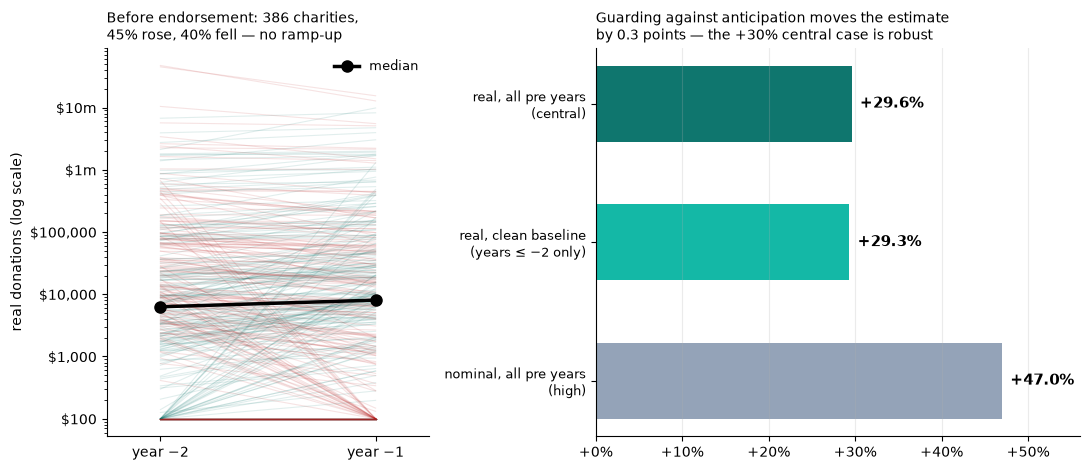

In [14]:
# Picture 5 — anticipation check, visually: paired slopes from -2 to -1
import matplotlib.pyplot as plt
import numpy as np

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 4.8), gridspec_kw={"width_ratios": [2, 3]})

# Left: every charity's -2 -> -1 move (log scale), coloured by direction
wp = w.clip(lower=100)
up = w[-1] > w[-2]
for i, (a, b) in enumerate(zip(wp[-2], wp[-1])):
    ax.plot([0, 1], [a, b], color="#0f766e" if up.iloc[i] else "#b91c1c",
            alpha=0.12, lw=0.8, zorder=1)
ax.plot([0, 1], [wp[-2].median(), wp[-1].median()], "o-", color="black", lw=2.5, ms=8, zorder=3,
        label="median")
ax.set_yscale("log")
ax.set_xticks([0, 1]); ax.set_xticklabels(["year −2", "year −1"])
ax.set_xlim(-0.25, 1.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}" if v < 1e6 else f"${v/1e6:g}m"))
ax.set_ylabel("real donations (log scale)")
ax.set_title(f"Before endorsement: {len(w)} charities,\n{(w[-1] > w[-2]).mean():.0%} rose, {(w[-1] < w[-2]).mean():.0%} fell — no ramp-up",
             fontsize=10, loc="left")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# Right: the three estimates side by side — the point of the whole section
bars = pd.DataFrame({
    "label": ["real, all pre years\n(central)", "real, clean baseline\n(years ≤ −2 only)", "nominal, all pre years\n(high)"],
    "value": [real["growth"].median(), clean["growth"].median(), nom["growth"].median()],
    "color": ["#0f766e", "#14b8a6", "#94a3b8"],
})
yp = np.arange(len(bars))
ax2.barh(yp, bars["value"], color=bars["color"], height=0.55)
for i, v in enumerate(bars["value"]):
    ax2.annotate(f"+{v:.1%}", (v, i), xytext=(6, 0), textcoords="offset points",
                 va="center", fontsize=11, fontweight="bold")
ax2.set_yticks(yp); ax2.set_yticklabels(bars["label"], fontsize=9.5)
ax2.invert_yaxis()
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"+{v:.0%}"))
ax2.set_xlim(0, 0.56)
ax2.set_title("Guarding against anticipation moves the estimate\nby 0.3 points — the +30% central case is robust",
              fontsize=10, loc="left")
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(axis="x", alpha=0.25)

fig.tight_layout()
plt.show()

## Step 6 — Summary table

In [7]:
summary = pd.DataFrame({
    "estimate": ["central (real)", "high (nominal)", "robustness: clean baseline (real)"],
    "definition": [
        "real $, pre = all years < 0, post = years >= 1",
        "nominal $, same pre/post",
        "real $, pre restricted to years <= -2",
    ],
    "median_uplift": [real["growth"].median(), nom["growth"].median(), clean["growth"].median()],
    "n_charities": [len(real), len(nom), len(clean)],
})
summary["median_uplift"] = (100 * summary["median_uplift"]).round(1).astype(str) + "%"
summary

,estimate,definition,median_uplift,n_charities
0,central (real),"real $, pre = all years < 0, post = years >= 1",29.6%,646
1,high (nominal),"nominal $, same pre/post",47.0%,646
2,robustness: clean baseline (real),"real $, pre restricted to years <= -2",29.3%,400


## Step 7 — How this squares with the elasticity / "$1.50" story

The advocacy framing (e.g. Justice Connect) assumes a **price elasticity of giving of −1** and a marginal tax rate of ~32%:

- Deductibility cuts the out-of-pocket cost of a \\$1 gift to \\$0.68.
- At elasticity −1, donors hold out-of-pocket spend constant, so gross gifts scale by $\tfrac{1}{1-0.32} = 1.47$ — a predicted uplift of **+47%** (the "\\$1.50", rounded).

**The convergence:** theory's prediction at elasticity −1 (+47%) matches our observed *nominal* median exactly; our real central (+30%) sits below it — consistent with donors responding strongly but somewhat less than one-for-one.

**Two caveats to carry into any presentation:**
1. Our uplift is the *combined* effect of individual deductibility **and** newly unlocked foundation/ancillary money — the AIS reports one donations line and cannot split the channels. So **don't add pool-access dollars on top of the +30%**: that double-counts.
2. Strictly, "\\$1 of tax foregone → \\$1.50 to charities" requires elasticity ≈ −1.5. At −1 the swap is 1:1; the 1.47 is the gross-up on the *donor's out-of-pocket sacrifice* (\\$0.68 becomes \\$1 at the charity), which is a different — but true — claim.

In [8]:
t = 0.32
print(f"Out-of-pocket cost of a $1 gift with deductibility: ${1 - t:.2f}")
print(f"Gross-up factor at elasticity -1: 1/(1-{t}) = {1 / (1 - t):.2f}  (+{t / (1 - t):.0%})")
print(f"\nObserved: nominal {nom['growth'].median():+.0%} | real {real['growth'].median():+.0%}")

implied = -real["growth"].median() / (t / (1 - t))
print(f"\nIf the entire real uplift were the price effect, implied elasticity ~ {implied:.2f}")
print("(an upper bound on magnitude - part of the uplift is foundation money, not price response)")

Out-of-pocket cost of a $1 gift with deductibility: $0.68
Gross-up factor at elasticity -1: 1/(1-0.32) = 1.47  (+47%)

Observed: nominal +47% | real +30%

If the entire real uplift were the price effect, implied elasticity ~ -0.63
(an upper bound on magnitude - part of the uplift is foundation money, not price response)


## Step 8 — The bridge: one dial connects the event study, the +47%, and the "\$1.50"

Everything in this debate is a position on a single dial: the **price elasticity of giving** ($\varepsilon$).
Gaining DGR endorsement cuts a donor's price of giving from \$1.00 to \$0.68 (at the ~32% marginal rate:
30% bracket + 2% Medicare levy). In the standard log-log model used throughout this literature — including
the PC's own Technical Paper (Appendix B) — giving scales as $(0.68)^{\varepsilon}$, so the predicted uplift
from gaining deductibility is $(1/0.68)^{|\varepsilon|} - 1$.

- **PC Finding 4.1** (ALife panel of 1.5m taxpayers, first Australian panel estimates): $\varepsilon$ between
  **−0.48 and −1.67** → predicted uplift **+20% to +90%**.
- **$\varepsilon = -1$** is the textbook benchmark *and* the treasury-efficiency threshold (PC Box B.1) → **+47%**.
- **The "\$1 → \$1.50" claim** requires $\varepsilon \approx -1.5$: at the margin, new giving per dollar of tax
  foregone equals $|\varepsilon|$ (PC Box B.1).
- **Our event study** measures the same dial from the other side: instead of donors facing marginal price
  variation, we observe 646 charities whose donors' price dropped from \$1.00 to \$0.68 all at once.
  The PC said this second strategy was "not feasible, given insufficient data" (Technical Paper, p. 421) —
  the ACNC panel makes it feasible.

The chart below places all four on the dial.


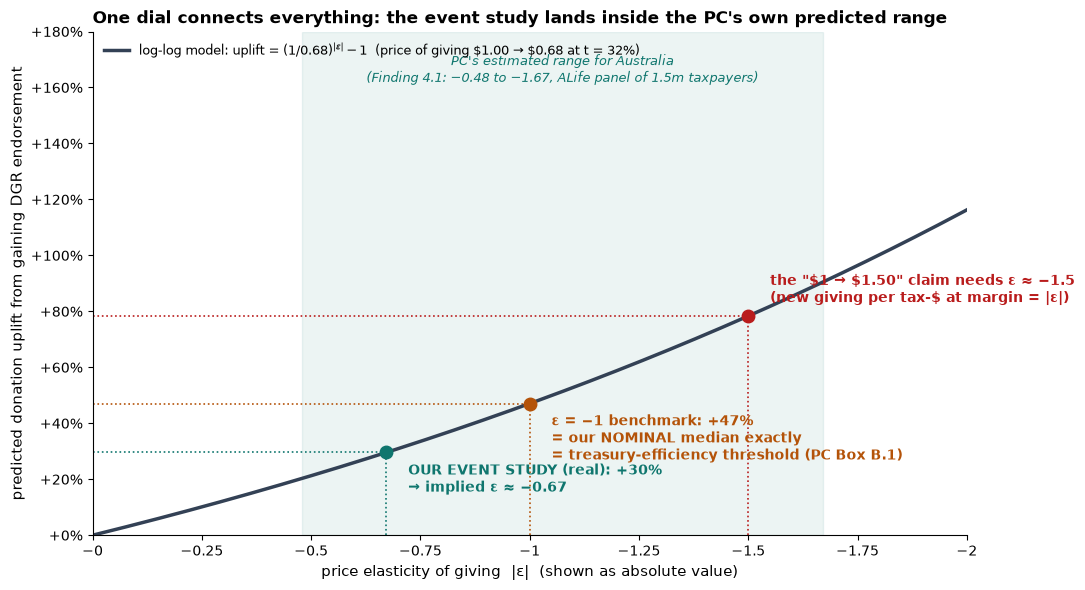

Implied elasticity from +29.6% real:    -0.67
Implied elasticity from +47.0% nominal: -1.00
PC range -0.48 to -1.67 -> predicted uplift +20% to +90%
New giving per $1 tax foregone at margin = |eps|: ours ~$0.67, benchmark $1.00, claim $1.50


In [25]:
# The bridge chart: donation uplift as a function of the price elasticity of giving.
# Our event study result is read off the SAME curve the PC / "$1.50" claims live on.
import matplotlib.pyplot as plt
import numpy as np

t = 0.32
price = 1 - t                       # donor's price of giving with deductibility = $0.68
eps = np.linspace(0, 2.0, 400)      # |elasticity|
uplift = (1 / price) ** eps - 1     # log-log model: g1/g0 = (p1/p0)^(-eps)

# our event study, read onto the dial
real_uplift = med_real_g            # ~+29.6% (real, CPI-deflated)
nom_uplift  = med_nom_g             # ~+47.0% (nominal)
eps_real = np.log(1 + real_uplift) / np.log(1 / price)   # implied |elasticity|
eps_nom  = np.log(1 + nom_uplift)  / np.log(1 / price)

# PC Finding 4.1 estimated range
pc_lo, pc_hi = 0.48, 1.67

fig, ax = plt.subplots(figsize=(11, 6))

# PC's estimated elasticity range as a band on the dial
ax.axvspan(pc_lo, pc_hi, color="#0f766e", alpha=0.08, zorder=0)
ax.text((pc_lo + pc_hi) / 2, 1.62, "PC's estimated range for Australia\n(Finding 4.1: \u22120.48 to \u22121.67, ALife panel of 1.5m taxpayers)",
        ha="center", fontsize=9.5, color="#0f766e", style="italic")

# the theory curve
ax.plot(eps, uplift, color="#334155", lw=2.5, zorder=2,
        label="log-log model: uplift = $(1/0.68)^{|\\varepsilon|}-1$  (price of giving \\$1.00 \u2192 \\$0.68 at t = 32%)")

def mark(e, u, color, label, dy, ha="left", dx=0.05):
    ax.plot([e, e], [0, u], color=color, lw=1.2, ls=":", zorder=1)
    ax.plot([0, e], [u, u], color=color, lw=1.2, ls=":", zorder=1)
    ax.plot(e, u, "o", color=color, ms=9, zorder=4)
    ax.annotate(label, xy=(e, u), xytext=(e + dx, u + dy), fontsize=10,
                fontweight="bold", color=color, ha=ha)

# 1) our real central estimate -> implied elasticity
mark(eps_real, real_uplift, "#0f766e",
     f"OUR EVENT STUDY (real): +{real_uplift:.0%}\n\u2192 implied \u03b5 \u2248 \u2212{eps_real:.2f}",
     dy=-0.14)

# 2) nominal = elasticity -1 benchmark
mark(1.0, (1 / price) ** 1.0 - 1, "#b45309",
     f"\u03b5 = \u22121 benchmark: +47%\n= our NOMINAL median exactly\n= treasury-efficiency threshold (PC Box B.1)",
     dy=-0.20)

# 3) the $1.50 claim
mark(1.5, (1 / price) ** 1.5 - 1, "#b91c1c",
     "the \"\\$1 \u2192 \\$1.50\" claim needs \u03b5 \u2248 \u22121.5\n(new giving per tax-\\$ at margin = |\u03b5|)",
     dy=0.05)

ax.set_xlim(0, 2.0)
ax.set_ylim(0, 1.8)
ax.set_xlabel("price elasticity of giving  |\u03b5|  (shown as absolute value)", fontsize=11)
ax.set_ylabel("predicted donation uplift from gaining DGR endorsement", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"+{v:.0%}"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"\u2212{v:g}"))
ax.set_title("One dial connects everything: the event study lands inside the PC's own predicted range",
             fontsize=12.5, fontweight="bold", loc="left")
ax.legend(loc="upper left", fontsize=9, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

print(f"Implied elasticity from +{real_uplift:.1%} real:    -{eps_real:.2f}")
print(f"Implied elasticity from +{nom_uplift:.1%} nominal: -{eps_nom:.2f}")
print(f"PC range -0.48 to -1.67 -> predicted uplift +{(1/price)**pc_lo-1:.0%} to +{(1/price)**pc_hi-1:.0%}")
print(f"New giving per $1 tax foregone at margin = |eps|: ours ~${eps_real:.2f}, benchmark $1.00, claim $1.50")

## Step 9 — Two measurement approaches, one parameter

The PC's Technical Paper (p. 421) names exactly two strategies for measuring the effect of deductibility. They took one; we took the other.

| | **PC: donor-side** | **Us: charity-side (event study)** |
|---|---|---|
| Unit of observation | individual taxpayers | individual charities |
| Data | ATO **ALife** — 10% longitudinal sample of tax returns, ~1.5m taxpayers, 2010-11 to 2018-19 | **ACNC AIS** panel × ABR endorsement dates, 62,612 charities, FY2019–24 |
| Price variation used | *marginal*: donors' price differs by tax bracket and shifts as incomes/rates change | *discrete*: a charity's donors go \$1.00 → \$0.68 all at once at endorsement |
| Identification | log-log fixed-effects + negative binomial, first-dollar price as regressor | within-charity before/after, staggered cohorts, placebo cohorts |
| Result | ε between **−0.48 and −1.67** (Finding 4.1) | median uplift **+30% real** → implied ε ≈ **−0.67** |
| Main weakness | never observes a charity *gaining* status; wide range | selection into applying; bundles price effect with signalling/eligibility effects |

**Can we replicate the PC's approach?** No — and it's worth being precise about why: ALife is restricted-access
ATO microdata (approved researchers, secure environment). No public dataset contains individual donors' gifts
and marginal tax rates. That is *the point* of our design: the PC judged the charity-side strategy "not feasible,
given insufficient data" — the ACNC panel joined to ABR endorsement dates makes it feasible, and it answers the
question the donor-side approach structurally cannot: *what actually happens to a charity's donations when it
gains DGR?*

**What we *can* replicate is the PC's uncertainty interval — from our own data.** The PC's −0.48 to −1.67 is a
range across model specifications. Our equivalent below combines (a) a bootstrap over the 646 charities and
(b) our specification variants (real / nominal / anticipation-robust baseline).

**And the "\$1 → \$1.50" semantics:** it means **\$1.50 of *extra* donations arrive at charities per \$1 of tax
revenue foregone** — not 50 cents extra. (The *net* gain over cost is the 50c.) The identity, from PC Box B.1:
at the margin, new giving per dollar of tax foregone $= |\varepsilon|$. So ε = −1.5 ⇒ \$1.50 of new gifts per
\$1 of cost; ε = −1 ⇒ \$1.00 per \$1 (break-even = "treasury efficiency"); our ε ≈ −0.67 ⇒ ~\$0.67 per marginal
tax dollar. The claim's wording is coherent — it just requires the top end of the elasticity range to be true.


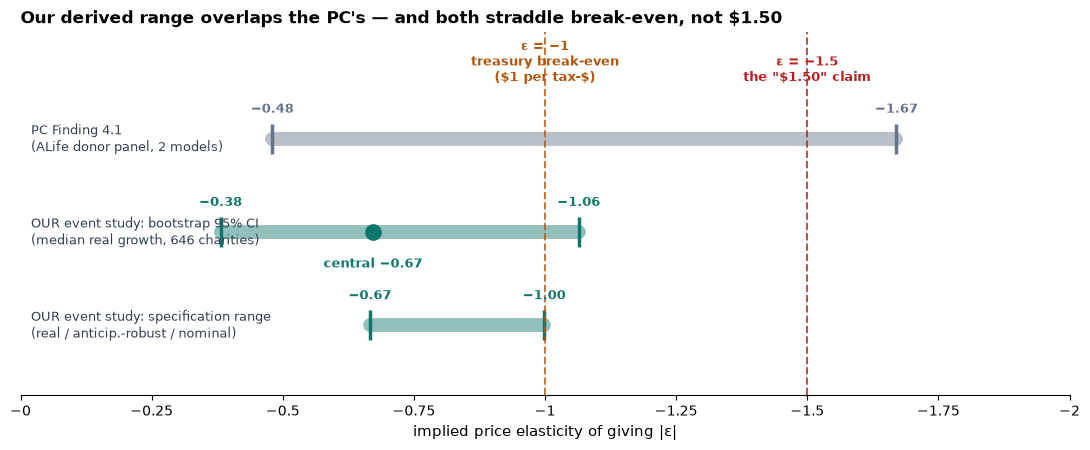

Bootstrap 95% CI, median real uplift: +15.8% to +50.8%  ->  eps -0.38 to -1.06
Specification range: real (central) +29.6% (eps -0.67), anticipation-robust +29.3% (eps -0.67), nominal +47.0% (eps -1.00)
OUR combined range: eps -0.38 to -1.06   (PC: -0.48 to -1.67)
New gifts per marginal tax-$: ours $0.38-$1.06, break-even $1.00, claim $1.50


In [26]:
# Our own elasticity RANGE, derived the same two ways the PC's range arises:
# (a) sampling uncertainty  — bootstrap the 646 charities, 10,000 draws
# (b) specification choices — real vs nominal vs anticipation-robust baseline
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(42)
t, price = 0.32, 0.68
to_eps = lambda u: np.log(1 + u) / np.log(1 / price)   # uplift -> implied |elasticity|

# (a) bootstrap the median real growth across charities
growth_real = real["growth"].to_numpy()
n = len(growth_real)
boot_med = np.median(
    growth_real[rng.integers(0, n, size=(10_000, n))], axis=1
)
lo_u, hi_u = np.percentile(boot_med, [2.5, 97.5])
boot_eps = (to_eps(lo_u), to_eps(hi_u))

# (b) specification variants already computed in this notebook
CLEAN_BASELINE = 0.293    # Step 4: pre restricted to event_year <= -2 (anti-anticipation), n=400
specs = {
    "real (central)": float(med_real_g),
    "anticipation-robust": CLEAN_BASELINE,
    "nominal": float(med_nom_g),
}
spec_eps = {k: to_eps(v) for k, v in specs.items()}
our_lo = min(min(spec_eps.values()), boot_eps[0])
our_hi = max(max(spec_eps.values()), boot_eps[1])

# ---- interval comparison chart -------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 4.6))
rows = [
    ("PC Finding 4.1\n(ALife donor panel, 2 models)", 0.48, 1.67, "#64748b", None),
    ("OUR event study: bootstrap 95% CI\n(median real growth, 646 charities)", *boot_eps, "#0f766e", to_eps(float(med_real_g))),
    ("OUR event study: specification range\n(real / anticip.-robust / nominal)", min(spec_eps.values()), max(spec_eps.values()), "#0f766e", None),
]
for y, (lbl, lo, hi, c, dot) in enumerate(reversed(rows)):
    ax.plot([lo, hi], [y, y], lw=10, color=c, alpha=0.45, solid_capstyle="round")
    ax.plot([lo, hi], [y, y], "|", ms=22, color=c, mew=2.5)
    for v_, side in [(lo, "right"), (hi, "left")]:
        ax.annotate(f"\u2212{v_:.2f}", xy=(v_, y), xytext=(v_, y + 0.28),
                    ha="center", fontsize=9, color=c, fontweight="bold")
    if dot is not None:
        ax.plot(dot, y, "o", ms=11, color=c, zorder=5)
        ax.annotate(f"central \u2212{dot:.2f}", xy=(dot, y), xytext=(dot, y - 0.38),
                    ha="center", fontsize=9, color=c, fontweight="bold")
    ax.annotate(lbl, xy=(0.02, y), fontsize=9.5, va="center", color="#334155")

# reference verticals
for v_, lbl, c in [(1.0, "\u03b5 = \u22121\ntreasury break-even\n(\\$1 per tax-\\$)", "#b45309"),
                   (1.5, "\u03b5 = \u22121.5\nthe \"\\$1.50\" claim", "#b91c1c")]:
    ax.axvline(v_, color=c, lw=1.4, ls="--", alpha=0.8)
    ax.annotate(lbl, xy=(v_, 2.62), ha="center", fontsize=9, color=c, fontweight="bold")

ax.set_xlim(0, 2.0)
ax.set_ylim(-0.75, 3.15)
ax.set_yticks([])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v_, _: f"\u2212{v_:g}"))
ax.set_xlabel("implied price elasticity of giving |\u03b5|", fontsize=11)
ax.set_title("Our derived range overlaps the PC's — and both straddle break-even, not \\$1.50",
             fontsize=12.5, fontweight="bold", loc="left")
ax.spines[["top", "right", "left"]].set_visible(False)
fig.tight_layout()
plt.show()

print(f"Bootstrap 95% CI, median real uplift: +{lo_u:.1%} to +{hi_u:.1%}"
      f"  ->  eps -{boot_eps[0]:.2f} to -{boot_eps[1]:.2f}")
print(f"Specification range: " + ", ".join(f"{k} +{v:.1%} (eps -{spec_eps[k]:.2f})" for k, v in specs.items()))
print(f"OUR combined range: eps -{our_lo:.2f} to -{our_hi:.2f}   (PC: -0.48 to -1.67)")
print(f"New gifts per marginal tax-$: ours ${our_lo:.2f}-${our_hi:.2f}, break-even $1.00, claim $1.50")